In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from PIL import Image
import matplotlib.pyplot as plt

import torchvision.transforms as transforms
from torchvision.models import vgg19, VGG19_Weights

import copy

import os
from datetime import datetime

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

In [3]:
# desired size of the output image
imsize = 512 if torch.cuda.is_available() else 128  # use small size if no GPU
imsize = 256
target_size = [imsize, imsize]
loader = transforms.Compose([
    transforms.Resize(target_size),  # scale imported image
    transforms.ToTensor()])  # transform it into a torch tensor


def image_loader(image_name):
    image = Image.open(image_name)
    # fake batch dimension required to fit network's input dimensions
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)


# style_img = image_loader("picasso.jpg")
# content_img = image_loader("crowly.JPG")

#assert style_img.size() == content_img.size(), \
 #   "we need to import style and content images of the same size"

In [4]:
unloader = transforms.ToPILImage()  # reconvert into PIL image

#plt.ion()

def imshow(tensor,tensor2, title=None, title2=None):
    image = tensor.cpu().clone()  # we clone the tensor to not do changes on it
    image = image.squeeze(0)      # remove the fake batch dimension
    image = unloader(image)
    plt.imsave("Saida.jpg", image)
    plt.subplot(1,2,1)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    image2 = tensor2.cpu().clone()  # we clone the tensor to not do changes on it
    image2 = image2.squeeze(0)      # remove the fake batch dimension
    image2 = unloader(image2)
    plt.subplot(1,2,2)
    plt.imshow(image2)
    if title2 is not None:
        plt.title(title2)
    plt.pause(0.001) # pause a bit so that plots are updated

    plt.show()

    
#plt.figure()
#imshow(style_img, title='Style Image')

#plt.figure()
#imshow(content_img, title='Content Image')

In [5]:
class ContentLoss(nn.Module):

    def __init__(self, target,):
        super(ContentLoss, self).__init__()
        # we 'detach' the target content from the tree used
        # to dynamically compute the gradient: this is a stated value,
        # not a variable. Otherwise the forward method of the criterion
        # will throw an error.
        self.target = target.detach()

    def forward(self, input):
        self.loss = F.mse_loss(input, self.target)
        return input

In [6]:
def gram_matrix(input):
    a, b, c, d = input.size()  # a=batch size(=1)
    # b=number of feature maps
    # (c,d)=dimensions of a f. map (N=c*d)

    features = input.view(a * b, c * d)  # resize F_XL into \hat F_XL

    G = torch.mm(features, features.t())  # compute the gram product

    # we 'normalize' the values of the gram matrix
    # by dividing by the number of element in each feature maps.
    return G.div(a * b * c * d)

In [7]:
class StyleLoss(nn.Module):

    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = F.mse_loss(G, self.target)
        return input

In [8]:
cnn = vgg19(weights=VGG19_Weights.DEFAULT).features.eval()

In [9]:
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406])
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225])

# create a module to normalize input image so we can easily put it in a
# ``nn.Sequential``
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        # .view the mean and std to make them [C x 1 x 1] so that they can
        # directly work with image Tensor of shape [B x C x H x W].
        # B is batch size. C is number of channels. H is height and W is width.
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std = torch.tensor(std).view(-1, 1, 1)

    def forward(self, img):
        # normalize ``img``
        return (img - self.mean) / self.std

In [10]:
# desired depth layers to compute style/content losses :
content_layers_default = ['conv_4']
style_layers_default = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

def get_style_model_and_losses(cnn, normalization_mean, normalization_std,
                               style_img, content_img,
                               content_layers=content_layers_default,
                               style_layers=style_layers_default):
    # normalization module
    normalization = Normalization(normalization_mean, normalization_std)

    # just in order to have an iterable access to or list of content/style
    # losses
    content_losses = []
    style_losses = []

    # assuming that ``cnn`` is a ``nn.Sequential``, so we make a new ``nn.Sequential``
    # to put in modules that are supposed to be activated sequentially
    model = nn.Sequential(normalization)

    i = 0  # increment every time we see a conv
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = 'conv_{}'.format(i)
        elif isinstance(layer, nn.ReLU):
            name = 'relu_{}'.format(i)
            # The in-place version doesn't play very nicely with the ``ContentLoss``
            # and ``StyleLoss`` we insert below. So we replace with out-of-place
            # ones here.
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = 'pool_{}'.format(i)
        elif isinstance(layer, nn.BatchNorm2d):
            name = 'bn_{}'.format(i)
        else:
            raise RuntimeError('Unrecognized layer: {}'.format(layer.__class__.__name__))

        model.add_module(name, layer)

        if name in content_layers:
            # add content loss:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module("content_loss_{}".format(i), content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            # add style loss:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module("style_loss_{}".format(i), style_loss)
            style_losses.append(style_loss)

    # now we trim off the layers after the last content and style losses
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
            break

    model = model[:(i + 1)]

    return model, style_losses, content_losses

In [11]:
def get_input_optimizer(input_img):
    # this line to show that input is a parameter that requires a gradient
    optimizer = optim.LBFGS([input_img])
    return optimizer

In [12]:
def run_style_transfer(cnn, normalization_mean, normalization_std,
                       content_img, style_img, input_img, num_steps=300,
                       style_weight=1000000, content_weight=1):
    """Run the style transfer."""
    print('Building the style transfer model..')
    model, style_losses, content_losses = get_style_model_and_losses(cnn,
        normalization_mean, normalization_std, style_img, content_img)

    # We want to optimize the input and not the model parameters so we
    # update all the requires_grad fields accordingly
    input_img.requires_grad_(True)
    # We also put the model in evaluation mode, so that specific layers
    # such as dropout or batch normalization layers behave correctly.
    model.eval()
    model.requires_grad_(False)

    optimizer = get_input_optimizer(input_img)

    print('Optimizing..')
    run = [0]
    while run[0] <= num_steps:

        def closure():
            # correct the values of updated input image
            with torch.no_grad():
                input_img.clamp_(0, 1)

            optimizer.zero_grad()
            model(input_img)
            style_score = 0
            content_score = 0

            for sl in style_losses:
                style_score += sl.loss
            for cl in content_losses:
                content_score += cl.loss

            style_score *= style_weight
            content_score *= content_weight

            loss = style_score + content_score
            loss.backward()

            run[0] += 1
            if run[0] % 50 == 0:
                print("run {}:".format(run))
                print('Style Loss : {:4f} Content Loss: {:4f}'.format(
                    style_score.item(), content_score.item()))
                print()

            return style_score + content_score

        optimizer.step(closure)

    # a last correction...
    with torch.no_grad():
        input_img.clamp_(0, 1)

    return input_img

In [13]:
def save_image(tensor, filename):
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = unloader(image) # 'unloader' já está definido no seu notebook
    image.save(filename)
    print(f"Imagem salva como: {filename}")

In [14]:
def transfer_style(style_img_path, content_img_path, num_steps=300,target_size = [512,512]):
    target_size = target_size
    loader = transforms.Compose([
        transforms.Resize(target_size),  # scale imported image
        transforms.ToTensor()])  # transform it into a torch tensor
    
    def image_loader(image_name):
        image = Image.open(image_name)
        # fake batch dimension required to fit network's input dimensions
        image = loader(image).unsqueeze(0)
        return image.to(device, torch.float)
    
    style_img = image_loader(style_img_path)
    content_img = image_loader(content_img_path)
    input_img = content_img.clone()
    
    output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                                content_img, style_img, input_img, num_steps=num_steps, style_weight=1000000, content_weight=1)

    plt.figure(figsize=(12,8))
    imshow(output, content_img, title='Output Image', title2="Original Image")
    plt.ioff()
    plt.show()

    style_name = os.path.basename(style_img_path).split('.')[0]
    content_name = os.path.basename(content_img_path).split('.')[0]
    
    # Cria um nome de arquivo único
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_filename = f"estilo_{style_name}_conteudo_{content_name}_{timestamp}.jpg"
    
    # Salva a imagem usando a função de salvamento
    save_image(output, output_filename)
    
    del style_img
    del content_img
    del input_img
    del output
    torch.cuda.empty_cache()

In [15]:
# transfer_style('/kaggle/input/dataset-fotos-style/fotos/style/van.jpg', '/kaggle/input/dataset-fotos-style/fotos/compose/crowly.jpg', num_steps=600, imsize=1024)

In [16]:
# transfer_style('/kaggle/input/dataset-fotos-style/fotos/style/van.jpg', '/kaggle/input/dataset-fotos-style/fotos/compose/house.jpg', num_steps=600, imsize = 1024)

In [17]:

style_img_path = "/kaggle/input/dataset-fotos-style/fotos/style/Starry_Night.jpg"
content_img_path = "/kaggle/input/dataset-fotos-style/fotos/compose/IMG_9733.JPG"
# transfer_style(style_img_path, content_img_path, num_steps=400,target_size = [3456 // 5, 5184 // 5])

In [18]:
style_img_path = "/kaggle/input/dataset-fotos-style/fotos/style/vincent_ajustada.jpg"
content_img_path = "/kaggle/input/dataset-fotos-style/fotos/compose/IMG_9733.JPG"
# transfer_style(style_img_path, content_img_path, num_steps=400,target_size = [1024, 1024])

In [19]:

style_img_path = "/kaggle/input/dataset-fotos-style/fotos/style/Starry_Night.jpg"
content_img_path = "/kaggle/input/dataset-fotos-style/fotos/compose/IMG_0103.JPG"
# transfer_style(style_img_path, content_img_path, num_steps=400,target_size = [512, 512])

In [20]:

style_img_path = "/kaggle/input/dataset-fotos-style/fotos/style/night.jpg"
content_img_path = "/kaggle/input/dataset-fotos-style/fotos/compose/IMG_0103.JPG"
# transfer_style(style_img_path, content_img_path, num_steps=400,target_size = [3456 // 3, 5184 // 3])

In [21]:

style_img_path = "/kaggle/input/dataset-fotos-style/fotos/style/night.jpg"
content_img_path = "/kaggle/input/dataset-fotos-style/fotos/compose/IMG-20250905-WA0046.jpg"
# transfer_style(style_img_path, content_img_path, num_steps=400,target_size = [3456 // 3, 5184 // 3])

In [22]:

style_img_path = "/kaggle/input/dataset-fotos-style/fotos/style/night.jpg"
content_img_path = "/kaggle/input/dataset-fotos-style/fotos/compose/IMG_0017.JPG"
# transfer_style(style_img_path, content_img_path, num_steps=400,target_size = [3456 // 3, 5184 // 3])

In [23]:

style_img_path = "/kaggle/input/dataset-fotos-style/fotos/style/Starry_Night.jpg"
content_img_path = "/kaggle/input/dataset-fotos-style/fotos/compose/IMG_0017.JPG"
# transfer_style(style_img_path, content_img_path, num_steps=400,target_size = [3456 // 3, 5184 // 3])

Building the style transfer model..
Optimizing..
run [50]:
Style Loss : 62.949520 Content Loss: 31.602160

run [100]:
Style Loss : 14.047827 Content Loss: 27.198709

run [150]:
Style Loss : 7.249503 Content Loss: 23.375887

run [200]:
Style Loss : 5.239450 Content Loss: 21.177055

run [250]:
Style Loss : 4.094746 Content Loss: 19.927366

run [300]:
Style Loss : 3.347797 Content Loss: 19.105806

run [350]:
Style Loss : 2.910259 Content Loss: 18.507658

run [400]:
Style Loss : 2.607366 Content Loss: 18.109650

run [450]:
Style Loss : 2.438606 Content Loss: 17.812609

run [500]:
Style Loss : 2.318491 Content Loss: 17.595514

run [550]:
Style Loss : 2.238819 Content Loss: 17.435102

run [600]:
Style Loss : 2.193066 Content Loss: 17.306948



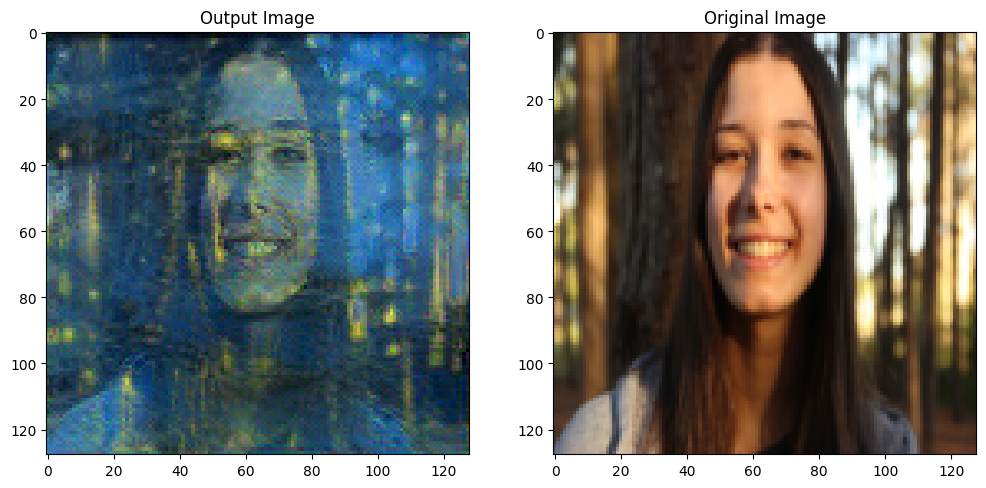

Imagem salva como: estilo_Starry_Night_conteudo_IMG_0319_20250908_120548.jpg


In [28]:
style_img_path = "fotos/style/Starry_Night.jpg"
content_img_path = "fotos/compose/IMG_0319.JPG"
transfer_style(style_img_path, content_img_path, num_steps=600, target_size=[128,128])